# Donchian-Breakout -- a quantitative teardown
### Real daily tape - 20-day channel - HAC return-diff inference - block-permutation placebo - planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_than_SMA%3F: Not_supported](https://img.shields.io/badge/Better_than_SMA%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We isolate the 20-day Donchian channel from the rest of the Turtle system and test, on 33 years of SPY plus a 7-ETF panel, whether the breakout's *timing* carries information beyond bull-market beta.

> **Not investment advice.** Real data: SPY daily total-return closes 1993-01-29 to 2026-06-12 (n=8,400), `auto_adjust=True`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> 💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from donchian_breakout import data, strategy as st

TICKER = "SPY"
N      = 20
COST   = 2.0   # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-23).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="bc9ada8a0d6f",
    in_mkt=62.2, n_switches=203,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59, bh_dd=-55.19, bh_t=3.67,
    dc_cagr=5.16, dc_sharpe=0.465, dc_vol=10.81, dc_dd=-41.86, dc_t=2.90,
    sma_cagr=3.68, sma_sharpe=0.325, sma_vol=11.13, sma_dd=-44.33, sma_t=1.94,
    rn_cagr=3.72, rn_sharpe=0.258, rn_vol=14.16, rn_dd=-70.05, rn_t=1.57,
    t_vs_bh=-2.32, t_vs_random=0.66, t_vs_sma=0.94,
    perm_real_bps=2.05, perm_p=0.83,
    sharpe_0bps=0.477, sharpe_1bps=0.471, sharpe_2bps=0.465,
    sharpe_5bps=0.449, sharpe_10bps=0.420,
    w10_sh=0.331, w10_t=-3.03, w20_sh=0.465, w20_t=-2.32,
    w55_sh=0.523, w55_t=-1.89, w100_sh=0.603, w100_t=-1.44,
    ls_sharpe=-0.015, ls_cagr=-0.27, ls_dd=-62.86, ls_t=-2.34,
    panel={
        "SPY": (0.465, 0.553, -2.32), "QQQ": (0.349, 0.385, -1.32),
        "IWM": (0.498, 0.461, -0.53), "TLT": (0.217, 0.255, -0.75),
        "GLD": (0.324, 0.553, -2.29), "USO": (0.183, -0.195, 1.57),
        "UUP": (-0.069, 0.197, -1.59),
    },
    syn_null_dc=-0.414, syn_null_bh=-0.295, syn_null_t=0.11, syn_null_p=0.92,
    syn_tr_dc=0.052, syn_tr_bh=-0.446, syn_tr_t=2.24, syn_tr_p=0.044,
)

HAVE_REAL = data.have_real(TICKER)
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    bars = data.load_real(TICKER)
    exp  = st.run_experiment(bars, n=N, cost_bps=COST, allow_short=False, random_seed=42)
    s_bh, s_dc, s_sma, s_rn = exp["bh"], exp["donchian"], exp["sma"], exp["random"]
    sig  = st.breakout_signal(bars, n=N, allow_short=False)
    bt   = st.run_backtest(bars, sig, cost_bps=COST)
    in_mkt = exp["in_market_frac"]
else:
    bars = sig = bt = None
    s_bh  = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], vol_ann=R["bh_vol"]/100, max_drawdown=R["bh_dd"]/100, tstat=R["bh_t"])
    s_dc  = dict(cagr=R["dc_cagr"]/100, sharpe=R["dc_sharpe"], vol_ann=R["dc_vol"]/100, max_drawdown=R["dc_dd"]/100, tstat=R["dc_t"])
    s_sma = dict(cagr=R["sma_cagr"]/100, sharpe=R["sma_sharpe"], vol_ann=R["sma_vol"]/100, max_drawdown=R["sma_dd"]/100, tstat=R["sma_t"])
    s_rn  = dict(cagr=R["rn_cagr"]/100, sharpe=R["rn_sharpe"], vol_ann=R["rn_vol"]/100, max_drawdown=R["rn_dd"]/100, tstat=R["rn_t"])
    exp   = dict(t_vs_bh=R["t_vs_bh"], t_vs_random=R["t_vs_random"], t_vs_sma=R["t_vs_sma"])
    in_mkt = R["in_mkt"]/100


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Donchian Sharpe 0.465 vs BH 0.553; return-diff HAC *t* = **-2.32** (loses); permutation placebo *p* = **0.83**; vs random *t* = +0.66; vs SMA *t* = +0.94. |
| **Tradability** | `MIRAGE` | Gross Sharpe 0.477 < BH 0.553; long/short Sharpe -0.015; fails the whole panel. |
| **Better than SMA?** | `NOT SUPPORTED` | Donchian vs SMA(20): *t* = +0.94 (indistinguishable); both lose to BH. |

> 💡 In plain words: the breakout's own *t* of +2.90 is real -- but it measures the rule's return against *zero*, and the rule is long 62% of the time in a rising market, so of course it's positive. The bar that matters is the return *against the benchmark*, and there the channel loses to buy-and-hold and ties both a coin and a plain moving average.

## 1 -- The claim, steelmanned

Let $H_t^{(N)} = \max_{1 \le k \le N} P_{t-k}$ and $L_t^{(N)} = \min_{1 \le k \le N} P_{t-k}$ be the Donchian channel (prior-$N$ high/low, both lagged so $t$ only sees the past). The long/flat position is a state machine: $w_t = 1$ once $P_t > H_t^{(N)}$, held until $P_t < L_t^{(N)}$ sets $w_t = 0$. Net return $r_t^{\text{strat}} = w_{t-1} r_t - c\,|w_t - w_{t-1}|$ (one execution lag, one-way cost $c$). Three hypotheses:

- **H1 (edge over beta).** $\text{SR}(\text{Donchian}) > \text{SR}(\text{BH})$ with |*t*| $\ge$ 2 on the daily return difference.
- **H2 (timing skill).** The breakout's days-in-market beat a block-shuffled schedule with the same exposure (permutation *p* small).
- **H3 (channel > MA).** $\text{SR}(\text{Donchian}) > \text{SR}(\text{SMA}(N))$ at the same window/lag/cost.

All three fail: H1 *t* = -2.32 (wrong sign), H2 *p* = 0.83, H3 *t* = +0.94.

## 2 -- So what? -- what rides on each answer

The channel breakout is the load-bearing entry of the most mythologised systematic experiment in trading (the Turtles). If the 20-day channel on a single liquid index beat buy-and-hold, it would be near-free alpha and strong evidence of monetisable trending in equity index prices. If it doesn't -- and especially if it can't beat a plain SMA -- then the Turtle legend's edge lives in the *rest* of the system (sizing, diversification across trending futures, pyramiding), not the breakout itself. That reattribution is the prize.

## 3 -- How we'd know -- the protocol

- **Signal.** Donchian(20) on SPY OHLC; channel lagged one bar (uses $\le t-1$), position lagged one more (entered at $t+1$) -- one documented execution lag.
- **Race.** Excess-vs-excess of the same flat-cash baseline; NET (one-way 2 bps × NAV on each switch; shorts pay 50 bps/yr borrow).
- **Benchmarks.** Buy-and-hold; SMA(20) cross (same window/lag/cost); random-timing control (matched in-market fraction, random days).
- **Inference.** HAC (Newey-West) *t* on each arm's mean and on the return *difference* (Jobson-Korkie); a 20-day **block-permutation placebo** for timing information.
- **Positive control.** Synthetic AR(1) tape with a planted return-autocorrelation `edge` knob: must light up at `edge>0`, stay null at `edge=0`.

## 4 -- The teardown

### 4a -- The four-arm net race

The headline table: does the channel beat the index, a moving average, or a coin?

In [2]:
print(f'In-market fraction: {in_mkt:.1%}')
print(f'\n{"Arm":14s}| {"CAGR":7s}| {"Sharpe":7s}| {"Vol":7s}| {"MaxDD":8s}| {"own t":6s}')
print('-'*60)
for lbl,s in [('Buy-and-hold',s_bh),('Donchian-20',s_dc),('SMA(20)',s_sma),('Random',s_rn)]:
    print(f'{lbl:14s}| {s["cagr"]:+.2%}| {s["sharpe"]:+.3f}| {s["vol_ann"]:.2%}| {s["max_drawdown"]:+.2%}| {s["tstat"]:+.2f}')
print(f'\nReturn-diff HAC t  Donchian vs BH:     {exp["t_vs_bh"]:+.2f}  (loses)')
print(f'Return-diff HAC t  Donchian vs random: {exp["t_vs_random"]:+.2f}  (tied)')
print(f'Return-diff HAC t  Donchian vs SMA(20):{exp["t_vs_sma"]:+.2f}  (tied)')


In-market fraction: 62.2%

Arm           | CAGR   | Sharpe | Vol    | MaxDD   | own t 
------------------------------------------------------------
Buy-and-hold  | +10.82%| +0.553| 18.59%| -55.19%| +3.67
Donchian-20   | +5.16%| +0.465| 10.81%| -41.86%| +2.90
SMA(20)       | +3.68%| +0.325| 11.13%| -44.33%| +1.94
Random        | +3.72%| +0.258| 14.16%| -70.05%| +1.57

Return-diff HAC t  Donchian vs BH:     -2.32  (loses)
Return-diff HAC t  Donchian vs random: +0.66  (tied)
Return-diff HAC t  Donchian vs SMA(20):+0.94  (tied)


> 💡 In plain words: the breakout's own *t* (+2.90) clears 2 -- but that just says 'this rule makes money', which any long-biased rule does in a bull market. The three *difference* t-stats are the real test, and they say: worse than holding, no better than a coin, no better than a moving average.

### 4b -- The block-permutation placebo: is there timing information?

Shuffle the position schedule in 20-day blocks (preserve the clustering of *being* positioned, destroy its alignment with returns) and ask how often a random schedule with the same exposure beats the real rule.

In [3]:
if HAVE_REAL:
    perm = st.permutation_pvalue(bars, sig, n_perm=2000, block=N, cost_bps=0.0, seed=437)
    p_val, real_bps = perm['p_value'], perm['real_mean_bps']
else:
    p_val, real_bps = R['perm_p'], R['perm_real_bps']
print(f'Real rule mean (gross): {real_bps:+.3f} bps/day')
print(f'Permutation p-value (2000 perms, block=20): {p_val:.3f}')
print(f'=> {p_val*100:.0f}% of random same-exposure schedules beat the real Donchian schedule.')


Real rule mean (gross): +2.046 bps/day
Permutation p-value (2000 perms, block=20): 0.830
=> 83% of random same-exposure schedules beat the real Donchian schedule.


> 💡 In plain words: *p* = 0.83 is about as null as it gets. If the channel were picking good entry days, the real rule would sit in the right tail (small *p*). Instead it sits in the middle-to-left: the breakout's chosen days are, if anything, slightly worse than random days with the same exposure. There is no timing signal in the 20-day high.

### 4c -- Window & cost sweeps -- is N=20 just unlucky?

The classic 20 is the *worst* short window; only very slow channels approach BH -- and none clear it (all return-diff t-stats stay in BH's favour). Costs are not the issue (low turnover).

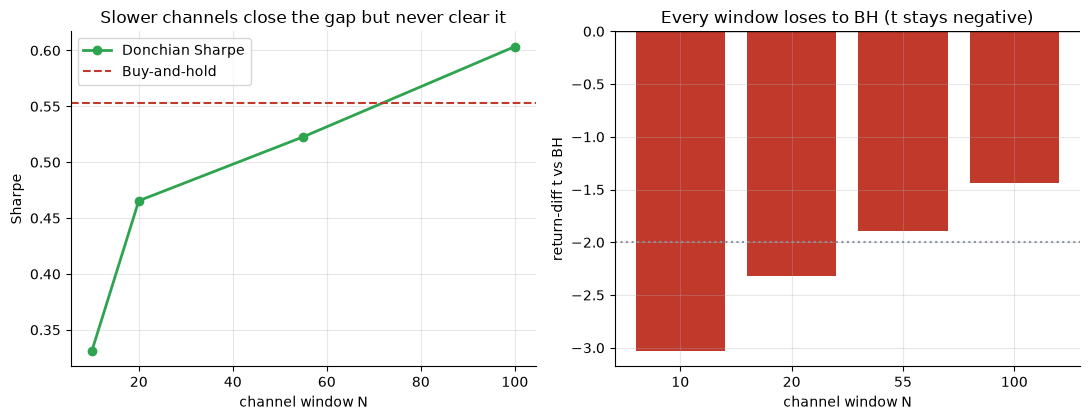

In [4]:
windows = [10,20,55,100]
if HAVE_REAL:
    w_sh, w_t = [], []
    for w in windows:
        e = st.run_experiment(bars, n=w, cost_bps=COST, random_seed=42)
        w_sh.append(e['donchian']['sharpe']); w_t.append(e['t_vs_bh'])
else:
    w_sh=[R['w10_sh'],R['w20_sh'],R['w55_sh'],R['w100_sh']]
    w_t =[R['w10_t'], R['w20_t'], R['w55_t'], R['w100_t']]
fig, ax = plt.subplots(1,2,figsize=(11,4.3))
ax[0].plot(windows, w_sh, 'o-', c=GREEN, lw=2, label='Donchian Sharpe')
ax[0].axhline(R['bh_sharpe'], ls='--', c=RED, label='Buy-and-hold')
ax[0].set_xlabel('channel window N'); ax[0].set_ylabel('Sharpe'); ax[0].legend()
ax[0].set_title('Slower channels close the gap but never clear it')
ax[1].bar([str(w) for w in windows], w_t, color=[RED if t<0 else GREEN for t in w_t])
ax[1].axhline(0, c='k', lw=1); ax[1].axhline(-2, ls=':', c=GREY)
ax[1].set_xlabel('channel window N'); ax[1].set_ylabel('return-diff t vs BH')
ax[1].set_title('Every window loses to BH (t stays negative)')
plt.tight_layout(); plt.show()


> 💡 In plain words: even hand-picking the friendliest window (N=100) only ties buy-and-hold, and a 100-day channel is no longer the '20-day breakout' of the folklore. There's no window where the *classic* rule wins.

### 4d -- The panel & the long/short blow-up

Across 7 liquid tapes the rule beats BH on none with significance; adding the short leg (short new 20-day lows) destroys it outright -- equities trend up, the short side bleeds.

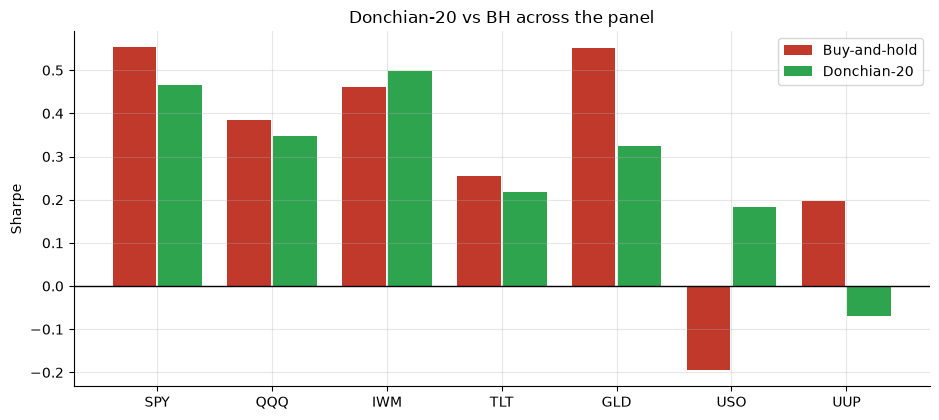

long/SHORT SPY (net): Sharpe -0.015  CAGR -0.27%  maxDD -62.9%  t_vs_bh -2.34


In [5]:
pan = R['panel']
if HAVE_REAL:
    pan = {}
    for t in data.PANEL:
        b = data.load_real(t)
        e = st.run_experiment(b, n=N, cost_bps=COST, random_seed=42)
        pan[t] = (e['donchian']['sharpe'], e['bh']['sharpe'], e['t_vs_bh'])
names = list(pan); dc=[pan[t][0] for t in names]; bh=[pan[t][1] for t in names]
x = np.arange(len(names)); fig,ax = plt.subplots(figsize=(9.5,4.3))
ax.bar(x-0.2, bh, width=0.38, color=RED, label='Buy-and-hold')
ax.bar(x+0.2, dc, width=0.38, color=GREEN, label='Donchian-20')
ax.axhline(0,c='k',lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Donchian-20 vs BH across the panel')
plt.tight_layout(); plt.show()
print('long/SHORT SPY (net): Sharpe %.3f  CAGR %.2f%%  maxDD %.1f%%  t_vs_bh %.2f' % (
      R['ls_sharpe'], R['ls_cagr'], R['ls_dd'], R['ls_t']))


### 4e -- Synthetic positive control: the engine *can* bank a real breakout

On a deterministic AR(1) tape with a planted return-autocorrelation `edge`, the breakout must light up when trend exists and stay null on a random walk.

In [6]:
rows = []
for edge, lbl in [(0.0,'Null (edge=0)'), (0.4,'Trend (edge=0.4)')]:
    sb,_ = data.synthetic_panel(n_days=6000, edge=edge, seed=437)
    e = st.run_experiment(sb, n=N, cost_bps=COST, random_seed=42)
    sg = st.breakout_signal(sb, n=N)
    pp = st.permutation_pvalue(sb, sg, n_perm=2000, block=N, seed=437)
    rows.append((lbl, e['donchian']['sharpe'], e['bh']['sharpe'], e['t_vs_bh'], pp['p_value']))
print(f'{"Tape":18s}| {"Donchian SR":12s}| {"BH SR":8s}| {"t vs BH":8s}| perm p')
for r in rows:
    print(f'{r[0]:18s}| {r[1]:+12.3f}| {r[2]:+8.3f}| {r[3]:+8.2f}| {r[4]:.3f}')


Tape              | Donchian SR | BH SR   | t vs BH | perm p
Null (edge=0)     |       -0.414|   -0.295|    +0.11| 0.920
Trend (edge=0.4)  |       +0.052|   -0.446|    +2.24| 0.044


> 💡 In plain words: with a real trend planted, the breakout beats buy-and-hold at *t* = +2.24 and the placebo lights up (*p* = 0.04). The harness works -- so SPY's null result is the engine correctly finding nothing, not the engine being blind. A planted *zero* edge stays null (*p* = 0.92), confirming the test can't manufacture significance from noise.

## 5 -- The verdict

- **Signal `NONE`** -- return-diff HAC *t* vs BH = -2.32 (loses), vs random = +0.66, vs SMA = +0.94; block-permutation placebo *p* = 0.83. The own-mean *t* of +2.90 is bull-market beta, not skill.
- **Tradability `MIRAGE`** -- gross Sharpe 0.477 < BH 0.553; long/short Sharpe -0.015; fails the whole panel. The only deliverable -- drawdown -42% vs -55% -- is just lower beta, replicable with a static split.
- **Better than SMA? `NOT SUPPORTED`** -- Donchian vs SMA(20): *t* = +0.94. Same window, same lag, same costs, statistically tied; the channel state machine adds nothing.

## 6 -- Could you trade it? -- capacity & costs

There is no edge to scale, but the cost geometry confirms the rule loses on *merit*, not on frictions: it sits below buy-and-hold even at zero cost.

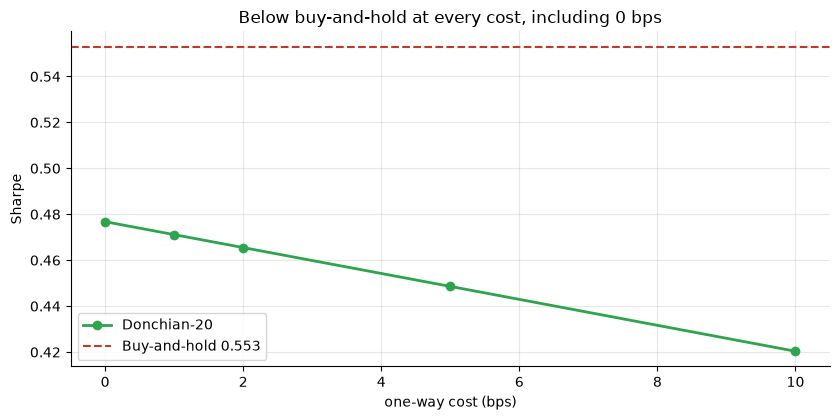

In [7]:
if HAVE_REAL:
    costs=[0.0,1.0,2.0,5.0,10.0]; shs=[]
    for c in costs:
        shs.append(st.run_experiment(bars, n=N, cost_bps=c, random_seed=42)['donchian']['sharpe'])
else:
    costs=[0.0,1.0,2.0,5.0,10.0]
    shs=[R['sharpe_0bps'],R['sharpe_1bps'],R['sharpe_2bps'],R['sharpe_5bps'],R['sharpe_10bps']]
fig,ax=plt.subplots(figsize=(8.5,4.3))
ax.plot(costs,shs,'o-',c=GREEN,lw=2,label='Donchian-20')
ax.axhline(R['bh_sharpe'],ls='--',c=RED,label=f'Buy-and-hold {R["bh_sharpe"]:.3f}')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('Below buy-and-hold at every cost, including 0 bps')
plt.tight_layout(); plt.show()


> 💡 In plain words: when a rule loses gross, costs and capacity are moot. The ~6 switches/yr make it cheap to run -- it just isn't worth running. A long-only holder beats it on return, Sharpe, and tax drag.

## 7 -- Going further

- **Reattribute the Turtle legend.** [Study 103 -- Turtle-Trader](../../103-turtle-trader/) runs the full system. This study is the controlled subtraction; together they locate the Turtles' edge in sizing/diversification/exits, not the 20-day entry.
- **The friendly home for breakouts.** Hurst-Ooi-Pedersen (2017) show trend rules earn a real, *diversified* premium across many futures. A fork applying Donchian-20/55 to a broad futures panel (commodities, FX, rates) is where the rule should be judged.
- **Why a slow SMA works and a fast channel doesn't.** [Study 110 -- Faber-Timing](../../110-faber-timing/) lands `REAL` on the risk axis because the 200-day SMA times volatility; the 20-day channel doesn't reach that horizon. Window and mechanism, not the channel-vs-band distinction, drive the difference.
- **Multiple-testing honesty.** Sullivan-Timmermann-White (1999) and Bajgrowicz-Scaillet (2012) show single-window breakout 'edges' evaporate under Reality-Check correction. Our permutation placebo is the same caution in miniature.

*Think the channel earns its keep somewhere? Fork this onto a diversified futures basket and show a significant return-diff t-stat vs buy-and-hold. That's the bar.*